# BA820 — Milestone 4 (Individual)

## Robustness checks on headline packaging and star-proxy patterns

This notebook is my **Milestone 4 individual extension** of the team’s M3 work on romantic age-gap inequality in Hollywood films.

In M3, our team built a multi-level framework connecting:

- **couple-level inequality** (age gaps, directionality, rule-of-seven violations),
- **movie-level packaging** (headline vs recurrence patterns in multi-couple films),
- and **director ecosystems**.

For M4, I focus on **testing the robustness of one key M3 mechanism**:

> whether the relationship between **within-film packaging concentration** and a **star-power proxy** is stable under different analytic choices.

This notebook is built **from scratch** (no dependence on previous runtime state). I first rebuild the key M3-derived tables and then run M4 robustness checks.

## 0) Setup

This cell imports the libraries used in the notebook, fixes a random seed for reproducibility, and creates output folders so all M4 results can be saved cleanly.

In [ ]:
# --- Setup ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr, mannwhitneyu

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

Path("data/derived").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

print("Setup done.")

Setup done.


## 1) Load raw data and apply shared preprocessing

Here I reload the shared `age_gaps.csv` dataset and recreate the couple-level variables used in M3 so the notebook is fully reproducible.

I keep the same shared definitions from M3 (to stay comparable with team results), including:

- `age_gap`
- `directionality` (`older_man`, `older_woman`, `other`)
- `is_large_gap` and `is_near_parity`
- rule-of-seven variables (`rule_threshold`, `rule_violation`)
- `decade`

This step gives me the baseline **couple-level table** that all later M4 analysis builds on.


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv"
df_raw = pd.read_csv(DATA_URL)

df_raw["age_gap"] = pd.to_numeric(df_raw["age_difference"], errors="coerce")

df = df_raw.dropna(subset=["movie_name", "release_year", "age_gap", "director"]).copy()
df["release_year"] = df["release_year"].astype(int)

MOVIE_KEY = ["movie_name", "release_year"]

# shared thresholds (same idea as M3)
LARGE_GAP = 20
PARITY_CUTOFF = 3

df["pairing_type"] = (
    df["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    df["character_2_gender"].astype(str).str.strip().str.lower()
)

df["directionality"] = np.select(
    [df["pairing_type"].eq("man–woman"), df["pairing_type"].eq("woman–man")],
    ["older_man", "older_woman"],
    default="other"
)

df["is_large_gap"] = df["age_gap"] >= LARGE_GAP
df["is_near_parity"] = df["age_gap"] <= PARITY_CUTOFF
df["decade"] = (df["release_year"] // 10) * 10

# rule-of-seven variables
df["older_age"] = df[["actor_1_age", "actor_2_age"]].max(axis=1)
df["younger_age"] = df[["actor_1_age", "actor_2_age"]].min(axis=1)
df["rule_threshold"] = (df["older_age"] / 2) + 7
df["rule_violation"] = df["younger_age"] < df["rule_threshold"]

df.shape, df.head(3)

((1155, 23),
            movie_name  release_year       director  age_difference  couple_number   actor_1_name     actor_2_name character_1_gender  \
 0    Harold and Maude          1971      Hal Ashby              52              1    Ruth Gordon         Bud Cort              woman   
 1               Venus          2006  Roger Michell              50              1  Peter O'Toole  Jodie Whittaker                man   
 2  The Quiet American          2002  Phillip Noyce              49              1  Michael Caine   Do Thi Hai Yen                man   
 
   character_2_gender actor_1_birthdate actor_2_birthdate  actor_1_age  actor_2_age  age_gap pairing_type directionality  is_large_gap  \
 0                man        1896-10-30        1948-03-29           75           23       52    woman–man    older_woman          True   
 1              woman        1932-08-02        1982-06-03           74           24       50    man–woman      older_man          True   
 2              woman  

## 2) Recreate era labels (M3 regime clustering)

To stay consistent with the M3 integrated pipeline, I recreate the **era/regime labels** using a simple KMeans clustering on:

- `release_year`
- `age_gap`

After clustering, I map clusters to interpretable labels (`Classic`, `Transition`, `Modern`) by ordering them by average release year.

This keeps the M4 tables compatible with the M3 structure even though the main focus here is packaging robustness.

In [ ]:
X_era = df[["release_year", "age_gap"]].copy()
X_era = X_era.fillna(0)

X_era_scaled = StandardScaler().fit_transform(X_era)

era_k = 3
era_model = KMeans(n_clusters=era_k, random_state=RANDOM_STATE, n_init=25)
df["era_cluster"] = era_model.fit_predict(X_era_scaled)

# label clusters by average year (low -> high)
era_bounds = (
    df.groupby("era_cluster")
    .agg(avg_year=("release_year", "mean"),
         start_year=("release_year", "min"),
         end_year=("release_year", "max"),
         n=("release_year", "size"))
    .sort_values("avg_year")
)

era_order = era_bounds.index.tolist()
era_label_map = {era_order[0]: "Classic", era_order[1]: "Transition", era_order[2]: "Modern"}
df["era_label"] = df["era_cluster"].map(era_label_map)

display(era_bounds)
df[["movie_name", "release_year", "age_gap", "era_label"]].head()

,avg_year,start_year,end_year,n
era_cluster,,,,
1,1961.968254,1935,1984,126
2,2004.720430,1971,2022,279
0,2005.864000,1982,2022,750


,movie_name,release_year,age_gap,era_label
0,Harold and Maude,1971,52,Transition
1,Venus,2006,50,Transition
2,The Quiet American,2002,49,Transition
3,The Big Lebowski,1998,45,Transition
4,Beginners,2010,43,Transition


## 3) Save the enriched couple-level table (M3-compatible artifact)

This cell saves an M3-compatible **couple-level enriched table** so I can reuse it downstream in a clean way.

Even though M4 focuses on movie-level robustness checks, keeping this intermediate artifact makes the pipeline easy to audit and reproduce.

In [ ]:
couple_cols = [
    "movie_name","release_year","director","couple_number",
    "age_gap","is_large_gap","is_near_parity",
    "pairing_type","directionality",
    "older_age","younger_age","rule_threshold","rule_violation",
    "decade","era_cluster","era_label",
    "actor_1_name","actor_2_name","character_1_gender","character_2_gender",
    "actor_1_age","actor_2_age"
]

couple_level_enriched = df[couple_cols].copy()
couple_level_enriched.to_csv("data/derived/couple_level_enriched.csv", index=False)

print("Saved: data/derived/couple_level_enriched.csv")
couple_level_enriched.head()

Saved: data/derived/couple_level_enriched.csv


,movie_name,release_year,director,couple_number,age_gap,is_large_gap,is_near_parity,pairing_type,directionality,older_age,younger_age,rule_threshold,rule_violation,decade,era_cluster,era_label,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,1,52,True,False,woman–man,older_woman,75,23,44.5,True,1970,2,Transition,Ruth Gordon,Bud Cort,woman,man,75,23
1,Venus,2006,Roger Michell,1,50,True,False,man–woman,older_man,74,24,44.0,True,2000,2,Transition,Peter O'Toole,Jodie Whittaker,man,woman,74,24
2,The Quiet American,2002,Phillip Noyce,1,49,True,False,man–woman,older_man,69,20,41.5,True,2000,2,Transition,Michael Caine,Do Thi Hai Yen,man,woman,69,20
3,The Big Lebowski,1998,Joel Coen,1,45,True,False,man–woman,older_man,68,23,41.0,True,1990,2,Transition,David Huddleston,Tara Reid,man,woman,68,23
4,Beginners,2010,Mike Mills,1,43,True,False,man–man,other,81,38,47.5,True,2010,2,Transition,Christopher Plummer,Goran Visnjic,man,man,81,38


## 4) Build multi-couple movie table and packaging metrics (M3 packaging layer)

This step recreates the M3 **movie packaging layer**.

I restrict the data to **multi-couple films** (`>= 2` couples), because packaging concentration only makes sense when a movie contains more than one romantic pair.

Then I compute movie-level packaging metrics such as:

- `max_gap`
- `second_gap`
- `top_gap_dominance` (largest gap − second largest gap)
- `headline_share` (`max_gap / sum_gap`)
- recurrence/dispersion features (`n_couples`, `median_gap`, `count_large`, etc.)

These features are the base for the packaging cluster labels used later in M4 robustness testing.

In [ ]:
couples_per_movie = couple_level_enriched.groupby(MOVIE_KEY).size().reset_index(name="n_couples")
df_counts = couple_level_enriched.merge(couples_per_movie, on=MOVIE_KEY, how="left")

multi_pairs = df_counts[df_counts["n_couples"] >= 2].copy()
print("Multi-couple rows:", multi_pairs.shape)

movie_summary = (
    multi_pairs.groupby(MOVIE_KEY)
    .agg(
        director=("director","first"),
        n_couples=("age_gap","size"),
        mean_gap=("age_gap","mean"),
        median_gap=("age_gap","median"),
        std_gap=("age_gap","std"),
        min_gap=("age_gap","min"),
        max_gap=("age_gap","max"),
        sum_gap=("age_gap","sum"),
        count_large=("age_gap", lambda x: (x >= LARGE_GAP).sum()),
        share_large=("age_gap", lambda x: (x >= LARGE_GAP).mean()),
    )
    .reset_index()
)

movie_summary["headline_share"] = movie_summary["max_gap"] / movie_summary["sum_gap"]
movie_summary["headline_score"] = movie_summary["max_gap"] - movie_summary["median_gap"]

# second largest gap + dominance
top2 = (
    multi_pairs.groupby(MOVIE_KEY)["age_gap"]
    .apply(lambda s: s.sort_values(ascending=False).head(2).tolist())
    .reset_index(name="top2_gaps")
)

top2[["max_gap2", "second_gap"]] = pd.DataFrame(top2["top2_gaps"].tolist(), index=top2.index)
top2["top_gap_dominance"] = top2["max_gap2"] - top2["second_gap"]
top2 = top2[MOVIE_KEY + ["second_gap", "top_gap_dominance"]]

movie_m = movie_summary.merge(top2, on=MOVIE_KEY, how="left")
movie_m["second_is_large"] = movie_m["second_gap"] >= LARGE_GAP

movie_m.head()

Multi-couple rows: (541, 23)


,movie_name,release_year,director,n_couples,mean_gap,median_gap,std_gap,min_gap,max_gap,sum_gap,count_large,share_large,headline_share,headline_score,second_gap,top_gap_dominance,second_is_large
0,10 Things I Hate About You,1999,Gil Junger,2,1.0,1.0,1.414214,0,2,2,0,0.0,1.000000,1.0,0,2,False
1,27 Dresses,2008,Anne Fletcher,2,7.5,7.5,3.535534,5,10,15,0,0.0,0.666667,2.5,5,5,False
2,A Happening of Monumental Proportions,2017,Judy Greer,2,4.0,4.0,5.656854,0,8,8,0,0.0,1.000000,4.0,0,8,False
3,A Perfect Murder,1998,Andrew Davis,2,21.0,21.0,9.899495,14,28,42,1,0.5,0.666667,7.0,14,14,False
4,A Simple Favor,2018,Paul Feig,2,1.0,1.0,1.414214,0,2,2,0,0.0,1.000000,1.0,0,2,False


## 5) Movie packaging clusters (KMeans)

Here I recreate the M3-style **movie packaging clusters** using interpretable packaging features.

I run a small silhouette scan (for context) and then keep a simple **3-cluster solution** to preserve comparability with the M3 packaging narrative:

- **Headline-dominant**
- **Recurrence-leaning**
- **Low-gap / typical**

This gives me the movie-level table that M4 will use for robustness checks.

,k,silhouette
0,2,0.471301
1,3,0.463567
2,4,0.411089
3,5,0.422828
4,6,0.336893


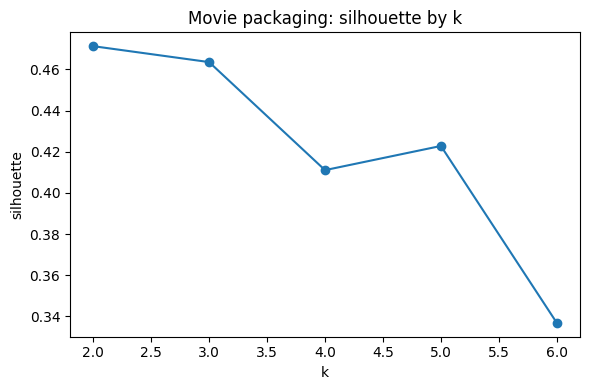

,top_gap_dominance,second_gap,median_gap,count_large,n_couples
movie_cluster,,,,,
0,20.0,7.5,16.25,1.0,2.0
1,4.0,4.0,6.50,0.0,2.0
2,5.0,18.0,20.00,1.0,3.0


Saved: data/derived/movie_level_multicouple.csv


,movie_name,release_year,director,n_couples,mean_gap,median_gap,std_gap,min_gap,max_gap,sum_gap,count_large,share_large,headline_share,headline_score,second_gap,top_gap_dominance,second_is_large,movie_cluster,movie_cluster_name
0,10 Things I Hate About You,1999,Gil Junger,2,1.0,1.0,1.414214,0,2,2,0,0.0,1.000000,1.0,0,2,False,1,Recurrence-leaning
1,27 Dresses,2008,Anne Fletcher,2,7.5,7.5,3.535534,5,10,15,0,0.0,0.666667,2.5,5,5,False,1,Recurrence-leaning
2,A Happening of Monumental Proportions,2017,Judy Greer,2,4.0,4.0,5.656854,0,8,8,0,0.0,1.000000,4.0,0,8,False,1,Recurrence-leaning
3,A Perfect Murder,1998,Andrew Davis,2,21.0,21.0,9.899495,14,28,42,1,0.5,0.666667,7.0,14,14,False,0,Headline-dominant
4,A Simple Favor,2018,Paul Feig,2,1.0,1.0,1.414214,0,2,2,0,0.0,1.000000,1.0,0,2,False,1,Recurrence-leaning


In [ ]:
features = ["top_gap_dominance", "second_gap", "median_gap", "count_large", "n_couples"]
X_movie = movie_m[features].dropna().copy()

X_movie_scaled = StandardScaler().fit_transform(X_movie)

# simple silhouette scan (not overdone)
Ks = range(2, 7)
sils = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_movie_scaled)
    sils.append(silhouette_score(X_movie_scaled, labels))

results = pd.DataFrame({"k": list(Ks), "silhouette": sils})
display(results)

plt.figure(figsize=(6, 4))
plt.plot(results["k"], results["silhouette"], marker="o")
plt.title("Movie packaging: silhouette by k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

k_movie = 3
kmeans_movie = KMeans(n_clusters=k_movie, random_state=RANDOM_STATE, n_init=25)
movie_used = movie_m.loc[X_movie.index].copy()
movie_used["movie_cluster"] = kmeans_movie.fit_predict(X_movie_scaled)

cluster_profile = movie_used.groupby("movie_cluster")[features].median().round(2)
display(cluster_profile)

# simple naming (edit if your medians suggest different labels)
cluster_names = {
    0: "Headline-dominant",
    1: "Recurrence-leaning",
    2: "Low-gap / typical"
}
movie_used["movie_cluster_name"] = movie_used["movie_cluster"].map(cluster_names)

movie_level_multicouple = movie_used.copy()
movie_level_multicouple.to_csv("data/derived/movie_level_multicouple.csv", index=False)

print("Saved: data/derived/movie_level_multicouple.csv")
movie_level_multicouple.head()

# M4 Section: Robustness Checks

From this point onward, the goal is **not** to rebuild the entire M3 analysis.

Instead, I use the recreated M3-style derived tables to test whether the main packaging finding remains stable under different choices:

- different **star-proxy definitions**
- **temporal split** (early vs late films)
- **parity threshold sensitivity** (3 vs 5)
- **bootstrap uncertainty** for key group differences

## 6) Rebuild a clean headline-couple table (one headline couple per movie)

In M3, a key improvement was replacing the invalid assumption that `couple_number` reflects narrative importance.

So here I define the **headline couple** as:

> the couple with the **maximum age gap** in a movie.

If a movie has ties, I break them deterministically using a **star proxy**, based on actor recurrence frequency in the full dataset.

I also create multiple proxy variants for robustness testing:

- `star_proxy_max`
- `star_proxy_older`
- `star_proxy_mean_pair`

This is the main M4 extension: checking whether findings depend on proxy definition.

In [ ]:
couples = couple_level_enriched.copy()
movies = movie_level_multicouple.copy()

max_gap_by_movie = (
    couples.groupby(MOVIE_KEY)["age_gap"]
    .max()
    .reset_index(name="movie_max_gap")
)

syn = couples.merge(max_gap_by_movie, on=MOVIE_KEY, how="left")
syn["is_headline_couple"] = syn["age_gap"] == syn["movie_max_gap"]

# star proxy base counts (recurrence across dataset)
actor_counts = pd.concat([couples["actor_1_name"], couples["actor_2_name"]]).value_counts()

syn["older_actor_freq"] = syn["actor_1_name"].map(actor_counts).fillna(0).astype(int)
syn["younger_actor_freq"] = syn["actor_2_name"].map(actor_counts).fillna(0).astype(int)

# proxy variants (M4 robustness dimension)
syn["star_proxy_max"] = syn[["older_actor_freq", "younger_actor_freq"]].max(axis=1)
syn["star_proxy_older"] = syn["older_actor_freq"]
syn["star_proxy_mean_pair"] = syn[["older_actor_freq", "younger_actor_freq"]].mean(axis=1)

# keep one headline couple per movie with deterministic tie-break
headline_one = (
    syn[syn["is_headline_couple"]]
    .sort_values(["age_gap", "star_proxy_max"], ascending=[False, False])
    .groupby(MOVIE_KEY, as_index=False)
    .head(1)
    .copy()
)

headline_one = headline_one[
    MOVIE_KEY + [
        "age_gap", "directionality", "rule_violation", "is_near_parity",
        "star_proxy_max", "star_proxy_older", "star_proxy_mean_pair",
        "era_label", "decade"
    ]
].rename(columns={"age_gap": "headline_age_gap"})

print("Movies with a headline couple:", headline_one.shape[0])
headline_one.head()

Movies with a headline couple: 838


,movie_name,release_year,headline_age_gap,directionality,rule_violation,is_near_parity,star_proxy_max,star_proxy_older,star_proxy_mean_pair,era_label,decade
0,Harold and Maude,1971,52,older_woman,True,False,1,1,1.0,Transition,1970
1,Venus,2006,50,older_man,True,False,1,1,1.0,Transition,2000
2,The Quiet American,2002,49,older_man,True,False,2,1,1.5,Transition,2000
3,The Big Lebowski,1998,45,older_man,True,False,2,1,1.5,Transition,1990
4,Beginners,2010,43,other,True,False,2,2,1.5,Transition,2010


## 7) Build the M4 movie-level analysis table

Now I merge headline-couple attributes onto the movie packaging table.

This creates the main **M4 analysis dataset**, where each row is a multi-couple movie and includes:

- packaging metrics (dominance, headline share, etc.)
- packaging cluster label
- headline-couple directionality / rule-violation indicators
- headline star-proxy variants

This table is used for all remaining robustness tests.

In [ ]:
m4_df = movies.merge(headline_one, on=MOVIE_KEY, how="left")
m4_df = m4_df.dropna(subset=["headline_age_gap"]).copy()

print("M4 movie-level analysis shape:", m4_df.shape)
m4_df.head()

M4 movie-level analysis shape: (224, 28)


,movie_name,release_year,director,n_couples,mean_gap,median_gap,std_gap,min_gap,max_gap,sum_gap,count_large,share_large,headline_share,headline_score,second_gap,top_gap_dominance,second_is_large,movie_cluster,movie_cluster_name,headline_age_gap,directionality,rule_violation,is_near_parity,star_proxy_max,star_proxy_older,star_proxy_mean_pair,era_label,decade
0,10 Things I Hate About You,1999,Gil Junger,2,1.0,1.0,1.414214,0,2,2,0,0.0,1.000000,1.0,0,2,False,1,Recurrence-leaning,2,older_man,False,True,5,5,4.0,Modern,1990
1,27 Dresses,2008,Anne Fletcher,2,7.5,7.5,3.535534,5,10,15,0,0.0,0.666667,2.5,5,5,False,1,Recurrence-leaning,10,older_man,False,False,3,1,2.0,Modern,2000
2,A Happening of Monumental Proportions,2017,Judy Greer,2,4.0,4.0,5.656854,0,8,8,0,0.0,1.000000,4.0,0,8,False,1,Recurrence-leaning,8,older_man,False,False,27,27,17.5,Modern,2010
3,A Perfect Murder,1998,Andrew Davis,2,21.0,21.0,9.899495,14,28,42,1,0.5,0.666667,7.0,14,14,False,0,Headline-dominant,28,older_man,True,False,7,6,6.5,Transition,1990
4,A Simple Favor,2018,Paul Feig,2,1.0,1.0,1.414214,0,2,2,0,0.0,1.000000,1.0,0,2,False,1,Recurrence-leaning,2,older_woman,False,True,5,5,4.0,Modern,2010


## 8) Baseline summary by movie packaging cluster

This summary reproduces the M3 integrated packaging story, but now adds the M4 headline-level variables.

I summarize each movie packaging cluster using:

- concentration metrics (`median_dominance`, `median_headline_share`)
- headline inequality markers (`pct_headline_older_man`, `pct_headline_rule_violation`)
- headline age gap
- headline star-proxy medians

This serves as the **baseline reference point** before running sensitivity tests.

In [ ]:
proxy_cols = ["star_proxy_max", "star_proxy_older", "star_proxy_mean_pair"]

cluster_summary = (
    m4_df.groupby("movie_cluster_name")
    .agg(
        n_movies=("movie_name","count"),
        median_dominance=("top_gap_dominance","median"),
        median_headline_share=("headline_share","median"),
        pct_headline_older_man=("directionality", lambda s: (s=="older_man").mean()),
        pct_headline_rule_violation=("rule_violation","mean"),
        mean_headline_gap=("headline_age_gap","mean"),
        median_star_max=("star_proxy_max","median"),
        median_star_older=("star_proxy_older","median"),
        median_star_mean_pair=("star_proxy_mean_pair","median"),
    )
    .reset_index()
)

for c in ["pct_headline_older_man", "pct_headline_rule_violation"]:
    cluster_summary[c] = (cluster_summary[c]*100).round(1)

cluster_summary["mean_headline_gap"] = cluster_summary["mean_headline_gap"].round(2)
cluster_summary["median_dominance"] = cluster_summary["median_dominance"].round(2)
cluster_summary["median_headline_share"] = cluster_summary["median_headline_share"].round(3)

display(cluster_summary.sort_values("n_movies", ascending=False))

,movie_cluster_name,n_movies,median_dominance,median_headline_share,pct_headline_older_man,pct_headline_rule_violation,mean_headline_gap,median_star_max,median_star_older,median_star_mean_pair
2,Recurrence-leaning,163,4.0,0.655,81.6,31.9,10.39,6.0,3.0,4.0
0,Headline-dominant,36,20.0,0.782,91.7,94.4,29.25,6.0,4.0,4.0
1,Low-gap / typical,25,5.0,0.469,92.0,96.0,25.60,8.0,7.0,6.0


## 9) Proxy sensitivity: do correlations hold across star-proxy definitions?

One concern from earlier milestones was that the actor recurrence proxy is imperfect.

So here I test whether the relationship between **packaging concentration** and **star proxy** changes depending on how star power is defined.

For each proxy variant, I compute Spearman correlations with:

- `top_gap_dominance`
- `headline_share`

If results are similar across proxies, that supports the robustness of the M3 interpretation.

,proxy,rho_vs_dominance,p_vs_dominance,rho_vs_headline_share,p_vs_headline_share
0,star_proxy_max,-0.0049,0.9416,-0.0633,0.3457
1,star_proxy_older,0.0164,0.8074,-0.0412,0.5397
2,star_proxy_mean_pair,-0.0088,0.8955,-0.0533,0.4271


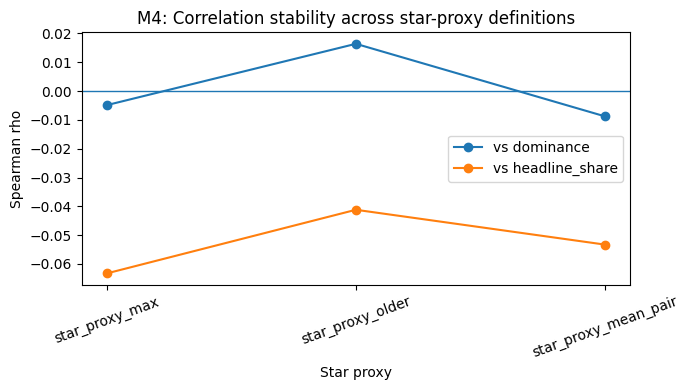

In [ ]:
rows = []
for p in proxy_cols:
    rho_dom, p_dom = spearmanr(m4_df["top_gap_dominance"], m4_df[p], nan_policy="omit")
    rho_share, p_share = spearmanr(m4_df["headline_share"], m4_df[p], nan_policy="omit")
    rows.append({
        "proxy": p,
        "rho_vs_dominance": rho_dom,
        "p_vs_dominance": p_dom,
        "rho_vs_headline_share": rho_share,
        "p_vs_headline_share": p_share
    })

proxy_sensitivity = pd.DataFrame(rows).round(4)
display(proxy_sensitivity)

plt.figure(figsize=(7, 4))
plt.plot(proxy_sensitivity["proxy"], proxy_sensitivity["rho_vs_dominance"], marker="o", label="vs dominance")
plt.plot(proxy_sensitivity["proxy"], proxy_sensitivity["rho_vs_headline_share"], marker="o", label="vs headline_share")
plt.axhline(0, linewidth=1)
plt.title("M4: Correlation stability across star-proxy definitions")
plt.xlabel("Star proxy")
plt.ylabel("Spearman rho")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## 10) Cluster comparison test: headline-dominant vs others (nonparametric)

This cell compares the star-proxy distributions in:

- **Headline-dominant** films
- **All other** packaging clusters combined

I use a **Mann–Whitney U test** (nonparametric) because the proxy values are count-based and not guaranteed to be normally distributed.

This tests whether headline-dominant packaging is systematically associated with higher star-proxy values.

In [ ]:
test_rows = []
for p in proxy_cols:
    hd = m4_df.loc[m4_df["movie_cluster_name"]=="Headline-dominant", p].dropna()
    other = m4_df.loc[m4_df["movie_cluster_name"]!="Headline-dominant", p].dropna()

    if len(hd) > 5 and len(other) > 5:
        u_stat, p_val = mannwhitneyu(hd, other, alternative="two-sided")
    else:
        p_val = np.nan

    test_rows.append({
        "proxy": p,
        "n_headline_dominant": len(hd),
        "n_other": len(other),
        "median_hd": float(hd.median()) if len(hd) else np.nan,
        "median_other": float(other.median()) if len(other) else np.nan,
        "mannwhitney_p": p_val
    })

proxy_cluster_tests = pd.DataFrame(test_rows).round(4)
display(proxy_cluster_tests)

,proxy,n_headline_dominant,n_other,median_hd,median_other,mannwhitney_p
0,star_proxy_max,36,188,6.0,6.00,0.9618
1,star_proxy_older,36,188,4.0,4.00,0.7783
2,star_proxy_mean_pair,36,188,4.0,4.25,0.9328


## 11) Temporal robustness: early vs late films

To check whether the M4 relationship is stable across time, I split the movie-level dataset into:

- **early** films
- **late** films

using the **median release year** as a simple split point.

Then I recompute the same Spearman correlations within each period for each star-proxy definition.

This helps test whether any observed relationship is time-specific or broadly stable.

In [ ]:
split_year = int(m4_df["release_year"].median())
m4_df["period"] = np.where(m4_df["release_year"] <= split_year, "early", "late")

print("Split year:", split_year)
display(m4_df["period"].value_counts())

period_rows = []
for period, part in m4_df.groupby("period"):
    for p in proxy_cols:
        rho_dom, p_dom = spearmanr(part["top_gap_dominance"], part[p], nan_policy="omit")
        rho_share, p_share = spearmanr(part["headline_share"], part[p], nan_policy="omit")
        period_rows.append({
            "period": period,
            "proxy": p,
            "n_movies": len(part),
            "rho_vs_dominance": rho_dom,
            "p_vs_dominance": p_dom,
            "rho_vs_headline_share": rho_share,
            "p_vs_headline_share": p_share
        })

period_proxy_results = pd.DataFrame(period_rows).round(4)
display(period_proxy_results)

Split year: 2005


,count
period,
early,113
late,111


,period,proxy,n_movies,rho_vs_dominance,p_vs_dominance,rho_vs_headline_share,p_vs_headline_share
0,early,star_proxy_max,113,-0.0794,0.4033,-0.1320,0.1634
1,early,star_proxy_older,113,-0.0933,0.3254,-0.1623,0.0859
2,early,star_proxy_mean_pair,113,-0.0824,0.3858,-0.1140,0.2293
3,late,star_proxy_max,111,0.0953,0.3200,0.0018,0.9850
4,late,star_proxy_older,111,0.1607,0.0919,0.1053,0.2714
5,late,star_proxy_mean_pair,111,0.0786,0.4125,-0.0161,0.8667


## 12) Parity threshold sensitivity (3 vs 5)

In M3, the team used a near-parity cutoff of **3 years** (with some discussion of 5 years as a sensitivity check).

Here I explicitly test both:

- `headline_near_parity_3`
- `headline_near_parity_5`

and compare the resulting percentages by movie packaging cluster.

This checks whether the packaging interpretation depends heavily on the strictness of the parity definition.

In [ ]:
for cutoff in [3, 5]:
    m4_df[f"headline_near_parity_{cutoff}"] = m4_df["headline_age_gap"] <= cutoff

parity_sensitivity = (
    m4_df.groupby("movie_cluster_name")
    .agg(
        n_movies=("movie_name","count"),
        pct_headline_near_parity_3=("headline_near_parity_3","mean"),
        pct_headline_near_parity_5=("headline_near_parity_5","mean"),
        pct_headline_older_man=("directionality", lambda s: (s=="older_man").mean()),
        pct_headline_rule_violation=("rule_violation","mean"),
    )
    .reset_index()
)

for c in ["pct_headline_near_parity_3","pct_headline_near_parity_5","pct_headline_older_man","pct_headline_rule_violation"]:
    parity_sensitivity[c] = (parity_sensitivity[c]*100).round(1)

display(parity_sensitivity.sort_values("n_movies", ascending=False))

,movie_cluster_name,n_movies,pct_headline_near_parity_3,pct_headline_near_parity_5,pct_headline_older_man,pct_headline_rule_violation
2,Recurrence-leaning,163,7.4,17.8,81.6,31.9
0,Headline-dominant,36,0.0,0.0,91.7,94.4
1,Low-gap / typical,25,0.0,0.0,92.0,96.0


## 13) Bootstrap uncertainty: median star-proxy difference (headline-dominant vs others)

Instead of relying only on point estimates, I use a simple **bootstrap** procedure to estimate uncertainty around the difference in median star proxy between:

- **Headline-dominant** films
- **Other** films

For each proxy definition, I report:

- bootstrap median difference
- 95% confidence interval

This makes the M4 interpretation more statistically cautious and transparent.

In [ ]:
def bootstrap_median_diff(x, y, n_boot=3000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan, np.nan

    diffs = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.median(xb) - np.median(yb))

    diffs = np.asarray(diffs)
    return float(np.median(diffs)), float(np.quantile(diffs, 0.025)), float(np.quantile(diffs, 0.975))

boot_rows = []
for p in proxy_cols:
    x = m4_df.loc[m4_df["movie_cluster_name"]=="Headline-dominant", p].dropna().values
    y = m4_df.loc[m4_df["movie_cluster_name"]!="Headline-dominant", p].dropna().values

    med_diff, ci_low, ci_high = bootstrap_median_diff(x, y, n_boot=3000, seed=RANDOM_STATE)
    boot_rows.append({
        "proxy": p,
        "median_diff_hd_minus_other": med_diff,
        "ci_low_95": ci_low,
        "ci_high_95": ci_high
    })

bootstrap_proxy_diff = pd.DataFrame(boot_rows).round(3)
display(bootstrap_proxy_diff)

,proxy,median_diff_hd_minus_other,ci_low_95,ci_high_95
0,star_proxy_max,0.0,-2.00,2.0
1,star_proxy_older,0.0,-1.50,2.5
2,star_proxy_mean_pair,0.0,-1.25,1.5


## 14) Key plot: dominance vs star proxy (clean scatter)

This is the main visual used in the M4 writeup.

It shows the relationship between:

- **top-gap dominance** (how concentrated the age-gap inequality is within the movie)
- **headline star proxy** (`star_proxy_max`)

I highlight **Headline-dominant** movies separately so the visual directly matches the cluster-based interpretation from M3.

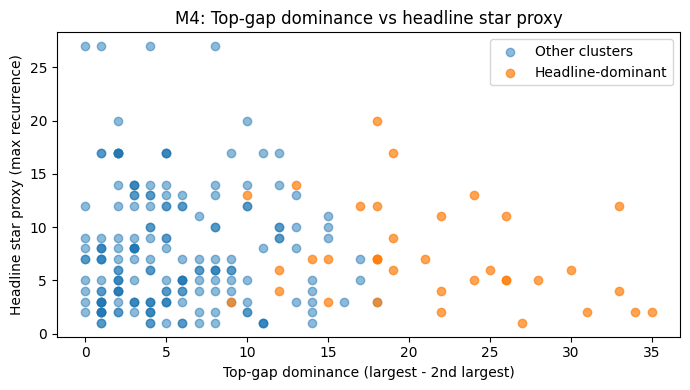

In [ ]:
plt.figure(figsize=(7, 4))
mask_hd = m4_df["movie_cluster_name"] == "Headline-dominant"

plt.scatter(m4_df.loc[~mask_hd, "top_gap_dominance"],
            m4_df.loc[~mask_hd, "star_proxy_max"],
            alpha=0.5, label="Other clusters")

plt.scatter(m4_df.loc[mask_hd, "top_gap_dominance"],
            m4_df.loc[mask_hd, "star_proxy_max"],
            alpha=0.7, label="Headline-dominant")

plt.title("M4: Top-gap dominance vs headline star proxy")
plt.xlabel("Top-gap dominance (largest - 2nd largest)")
plt.ylabel("Headline star proxy (max recurrence)")
plt.legend()
plt.tight_layout()
plt.show()

## 15) Save outputs for M4 writeup reproducibility

This final cell saves all M4 result tables to `outputs/` so the writeup can reference stable, reproducible artifacts.

Saved outputs include:

- baseline cluster summary
- proxy sensitivity results
- nonparametric cluster tests
- temporal robustness results
- parity sensitivity table
- bootstrap CI table
- final M4 movie-level analysis table

This makes the notebook easy to audit and aligns with the course requirement that reported results be traceable to code outputs.

In [ ]:
cluster_summary.to_csv("outputs/m4_cluster_summary.csv", index=False)
proxy_sensitivity.to_csv("outputs/m4_proxy_sensitivity.csv", index=False)
proxy_cluster_tests.to_csv("outputs/m4_proxy_cluster_tests.csv", index=False)
period_proxy_results.to_csv("outputs/m4_temporal_proxy_results.csv", index=False)
parity_sensitivity.to_csv("outputs/m4_parity_sensitivity.csv", index=False)
bootstrap_proxy_diff.to_csv("outputs/m4_bootstrap_proxy_diff.csv", index=False)
m4_df.to_csv("outputs/m4_movie_level_analysis_table.csv", index=False)

print("Saved M4 outputs:")
for f in sorted(Path("outputs").glob("m4_*.csv")):
    print("-", f.as_posix())

Saved M4 outputs:
- outputs/m4_bootstrap_proxy_diff.csv
- outputs/m4_cluster_summary.csv
- outputs/m4_movie_level_analysis_table.csv
- outputs/m4_parity_sensitivity.csv
- outputs/m4_proxy_cluster_tests.csv
- outputs/m4_proxy_sensitivity.csv
- outputs/m4_temporal_proxy_results.csv
